# EasyVitessce Example: SpatialData-Plot with Visium dataset

This notebook reproduces https://spatialdata.scverse.org/en/stable/tutorials/notebooks/notebooks/examples/technology_visium.html

<!--## Table of Contents

- SpatialData (via Zarr)
- AnnData via Zarr
- AnnData via H5AD
- OME-Zarr
- OME-TIFF
-->

## Import EasyVitessce

This import statement enables interactive plots by default.
Refer to the [EasyVitessce documentation](https://vitessce.github.io/easy_vitessce/) for how to disable interactive plotting or configure other behaviors.

In [12]:
import easy_vitessce as ev

## Utility dependencies

First, we import utility dependencies which will be used to download the example dataset and manipulate file paths, zip files, and JSON files.

In [13]:
import os
from os.path import join, isfile, isdir
from urllib.request import urlretrieve
import zipfile
import json

## Dependencies for data structures

In [14]:
from spatialdata import read_zarr

## Download example dataset

In [15]:
data_dir = "data"
zip_filepath = join(data_dir, "visium.spatialdata.zarr.zip")
spatialdata_filepath = join(data_dir, "visium.spatialdata.zarr")

The following code uses Python's `urlretrieve` to download the SpatialData object as a zip file, then unzips the file using the `zipfile` module.

In [16]:
if not isdir(spatialdata_filepath):
    if not isfile(zip_filepath):
        os.makedirs(data_dir, exist_ok=True)
        urlretrieve('https://vitessce-data-v2.s3.us-east-1.amazonaws.com/data/easy_vitessce/visium.zip', zip_filepath)
    with zipfile.ZipFile(zip_filepath,"r") as zip_ref:
        zip_ref.extractall(data_dir)
        os.rename(join(data_dir, "data_v2.zarr"), spatialdata_filepath)

## Read the example SpatialData object

In [17]:
sdata = read_zarr(spatialdata_filepath)
sdata

version mismatch: detected: RasterFormatV02, requested: FormatV04
/Users/ericmoerth/ws/easy_vitessce/.venv/lib/python3.13/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
version mismatch: detected: RasterFormatV02, requested: FormatV04
/Users/ericmoerth/ws/easy_vitessce/.venv/lib/python3.13/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
version mismatch: detected: RasterFormatV02, requested: FormatV04
/Users/ericmoerth/ws/easy_vitessce/.venv/lib/python3.13/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
version mismatch: detected: RasterFormatV02, requested: FormatV04
/Users/ericmoerth/ws/easy_vitessce/.venv/lib/python3.13/site-packages/zarr/creation.p

SpatialData object, with associated Zarr store: /Users/ericmoerth/ws/easy_vitessce/docs/notebooks/data/visium.spatialdata.zarr
├── Images
│     ├── 'ST8059048_hires_image': DataArray[cyx] (3, 2000, 1969)
│     ├── 'ST8059048_lowres_image': DataArray[cyx] (3, 600, 591)
│     ├── 'ST8059050_hires_image': DataArray[cyx] (3, 2000, 1968)
│     └── 'ST8059050_lowres_image': DataArray[cyx] (3, 600, 590)
├── Shapes
│     ├── 'ST8059048': GeoDataFrame shape: (2987, 2) (2D shapes)
│     └── 'ST8059050': GeoDataFrame shape: (3497, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (6484, 31053)
with coordinate systems:
    ▸ 'ST8059048', with elements:
        ST8059048_hires_image (Images), ST8059048 (Shapes)
    ▸ 'ST8059050', with elements:
        ST8059050_hires_image (Images), ST8059050 (Shapes)

## Plot the data

In [18]:
sdata.pl.render_images("ST8059050_hires_image").pl.render_shapes("ST8059050", color="Fth1").pl.show("ST8059050")

VitessceWidget(js_dev_mode=True, uid='c198')

## Disable EasyVitessce

In [19]:
ev.configure_plots(disable_plots=["spatialdata-plot"])

Deactivated Vitessce spatialdata-plot


## Generate a static plot using the same code

/Users/ericmoerth/ws/easy_vitessce/.venv/lib/python3.13/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 'ST8059048', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)


INFO     Rasterizing image for faster rendering.                                                                   


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.028571429..1.0].
/Users/ericmoerth/ws/easy_vitessce/.venv/lib/python3.13/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `ST8059050` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/Users/ericmoerth/ws/easy_vitessce/.venv/lib/python3.13/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `table` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


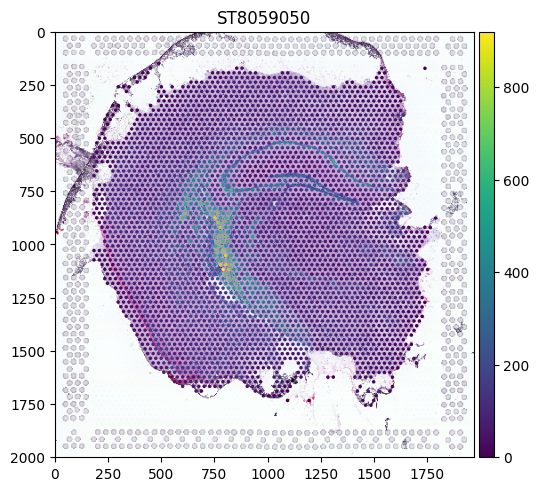

In [20]:
sdata.pl.render_images("ST8059050_hires_image").pl.render_shapes("ST8059050", color="Fth1").pl.show("ST8059050")